In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100


df = pd.read_csv("data/carPrices/train.csv")

In [3]:
df = df.loc[~df.duplicated(subset=["ID"])].reset_index(drop=True).copy()

In [4]:
df = df.drop(columns=['Levy', 'ID', 'Doors', 'Leather interior', 'Wheel', 'Airbags']).copy()

In [5]:
df = df[df['Cylinders'].isin([2, 3, 4, 5, 6, 8, 12])].copy()

In [6]:
df = df[df['Fuel type'] != 'Hydrogen'].copy()

In [7]:
color_map = {
    "Silver": "Silver",
    "Black": "Black",
    "White": "White",
    "Grey": "Gray",
    "Blue": "Blue",
    "Sky blue": "Blue",
    "Green": "Green",
    "Red": "Red",
    "Carnelian red": "Red",
    "Orange": "Orange",
    "Yellow": "Gold",
    "Brown": "Brown",
    "Golden": "Gold",
    "Beige": "Beige",
    "Purple": "Purple",
    "Pink": "Red",
}
df['Color'] = df['Color'].map(color_map)

In [8]:
df['Mileage'] = df['Mileage'].str.replace('km', '', regex=False)

In [9]:
df['Mileage'] = df['Mileage'].astype(float)

In [10]:
df = df[(df['Mileage'] >= 1000) & (df['Mileage'] <= 200000)].copy()

In [11]:
df['Mileage'] = df['Mileage'].astype(float)

In [12]:
df['Cylinders'] = df['Cylinders'].astype(float)

In [13]:
BODY_TYPE_MAP = {
    "Jeep": "SUV",
    "Hatchback": "Hatchback",
    "Sedan": "Sedan",
    "Microbus": "Van",
    "Goods wagon": "Van",
    "Universal": "Wagon",
    "Coupe": "Coupe",
    "Minivan": "Van",
    "Cabriolet": "Convertible",
    "Limousine": "Sedan",
    "Pickup": "Pickup",
}
df['Category'] = df['Category'].map(BODY_TYPE_MAP)

In [14]:
GEARBOX_TYPE_MAP = {
    "Automatic": "Automatic",
    "Tiptronic": "Automatic",
    "Variator": "Automatic",  # CVT
    "Manual": "Manual",
}

In [15]:
df['Gear box type'] = df['Gear box type'].map(GEARBOX_TYPE_MAP)

In [16]:
df['Gear box type'] = df['Gear box type'].map({'Manual': 1, 'Automatic': 0})

In [17]:
drive_wheels_map = {
    '4x4': 'AWD',
    'Front': 'FWD',
    'Rear': 'RWD'}
df['Drive wheels'] = df['Drive wheels'].map(drive_wheels_map)

In [18]:
fuel_type_map = {
    "Hybrid": "Hybrid",
    "Plug-in Hybrid": "Hybrid",
    "Petrol": "Petrol",
    "Diesel": "Diesel",
    "CNG": "Petrol",
    "LPG": "Petrol",
    "Hydrogen": "Electric",
}
df['Fuel type'] = df['Fuel type'].map(fuel_type_map)

In [19]:
import re
import pandas as pd

# -----------------------------
# 1) Supported makes
# -----------------------------
supported_makes = [
    "Toyota", "Hyundai", "Nissan", "Kia", "Honda", "Lexus", "GMC",
    "Chevrolet", "Ford", "Tesla", "BMW", "Mercedes-Benz", "Mitsubishi",
    "Land Rover", "Jeep", "Dodge", "Ram", "Volkswagen", "Audi", "Mazda",
    "Infiniti", "Cadillac", "Subaru"
]

make_lookup = {m.lower(): m for m in supported_makes}


# -----------------------------
# 2) Expanded supported models by make
#    Only for the makes above
# -----------------------------
supported_models_by_make = {
    "Toyota": [
        "Camry", "Corolla", "RAV4", "Highlander", "4Runner", "Tacoma", "Tundra",
        "Prius", "Prius C", "Prius V", "Sienna", "Sequoia", "Land Cruiser",
        "Land Cruiser Prado", "Crown", "Avalon", "C-HR", "Aqua", "Vitz",
        "Ist", "VOXY"
    ],
    "Hyundai": [
        "Elantra", "Sonata", "Tucson", "Santa Fe", "Palisade", "Kona", "Venue",
        "Santa Cruz", "Ioniq 5", "Ioniq 6", "Accent", "Genesis", "Grandeur",
        "Veloster", "i30", "H1"
    ],
    "Nissan": [
        "Altima", "Sentra", "Versa", "Rogue", "Murano", "Pathfinder", "Armada",
        "Frontier", "Leaf", "Kicks", "Z", "Juke", "Tiida", "Note", "March",
        "X-Trail", "Xterra", "Serena", "Skyline"
    ],
    "Kia": [
        "K4", "K5", "Forte", "Soul", "Seltos", "Sportage", "Sorento",
        "Telluride", "Carnival", "EV6", "EV9", "Optima", "Rio", "Picanto",
        "Cerato"
    ],
    "Honda": [
        "Accord", "Civic", "CR-V", "HR-V", "Pilot", "Odyssey", "Passport",
        "Ridgeline", "Prologue", "Fit", "Insight", "Elysion"
    ],
    "Lexus": [
        "RX 350", "RX 450", "NX 350", "ES 350", "ES 300", "GX 550", "GX 460",
        "GX 470", "LX 600", "LS 500", "LS 460", "IS 350", "IS 250",
        "RC 350", "TX 350", "UX 300h", "CT 200h", "HS 250h"
    ],
    "GMC": [
        "Terrain", "Acadia", "Yukon", "Yukon XL", "Canyon", "Sierra 1500",
        "Sierra HD", "Hummer EV"
    ],
    "Chevrolet": [
        "Trax", "Trailblazer", "Equinox", "Blazer", "Traverse", "Tahoe",
        "Suburban", "Colorado", "Silverado 1500", "Malibu", "Corvette",
        "Cruze", "Captiva", "Volt", "Orlando", "Spark", "Aveo", "Impala",
        "Camaro"
    ],
    "Ford": [
        "Maverick", "Ranger", "F-150", "Mustang", "Escape", "Bronco Sport",
        "Bronco", "Explorer", "Expedition", "Transit", "Fusion", "Focus",
        "Fiesta", "Taurus", "Transit Connect"
    ],
    "Tesla": [
        "Model 3", "Model Y", "Model S", "Model X", "Cybertruck"
    ],
    "BMW": [
        "2 Series", "3 Series", "4 Series", "5 Series", "7 Series",
        "X1", "X3", "X5", "X6", "X7", "i4", "iX"
    ],
    "Mercedes-Benz": [
        "C-Class", "E-Class", "S-Class", "CLA", "CLS", "GLA", "GLC",
        "GLE", "GLS", "GL", "ML", "EQB", "EQE", "G-Class", "Sprinter", "Vito"
    ],
    "Mitsubishi": [
        "Mirage", "Outlander", "Outlander Sport", "Eclipse Cross",
        "Pajero", "Pajero iO", "Airtrek", "Colt"
    ],
    "Land Rover": [
        "Range Rover", "Range Rover Sport", "Range Rover Velar",
        "Range Rover Evoque", "Discovery", "Defender"
    ],
    "Jeep": [
        "Compass", "Cherokee", "Grand Cherokee", "Wrangler", "Gladiator",
        "Wagoneer", "Grand Wagoneer"
    ],
    "Dodge": [
        "Hornet", "Durango", "Charger", "Challenger", "Caliber"
    ],
    "Ram": [
        "1500", "2500", "3500", "ProMaster"
    ],
    "Volkswagen": [
        "Jetta", "Taos", "Tiguan", "Atlas", "Atlas Cross Sport",
        "Golf GTI", "Golf R", "Golf", "ID.4", "Passat", "CC"
    ],
    "Audi": [
        "A3", "A4", "A5", "A6", "A7", "Q3", "Q5", "Q7", "Q8",
        "e-tron", "Q4 e-tron"
    ],
    "Mazda": [
        "Mazda3", "Mazda6", "CX-30", "CX-5", "CX-9", "CX-50",
        "CX-70", "CX-90", "MX-5 Miata", "MPV", "Demio"
    ],
    "Infiniti": [
        "Q50", "QX50", "QX55", "QX60", "QX80"
    ],
    "Cadillac": [
        "CT4", "CT5", "XT4", "XT5", "XT6", "Escalade", "Lyriq", "Optiq"
    ],
    "Subaru": [
        "Impreza", "Legacy", "WRX", "Crosstrek", "Forester", "Outback",
        "Ascent", "BRZ", "Solterra", "XV"
    ]
}


# -----------------------------
# 3) Normalization helpers
# -----------------------------
def normalize_text(s):
    s = str(s).strip().lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9\s\-]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def make_model_key(s):
    # stronger normalization for matching model variants
    s = normalize_text(s)
    s = s.replace("-", "")
    s = s.replace(" ", "")
    return s


# -----------------------------
# 4) Normalize manufacturer first
# -----------------------------
df["Manufacturer"] = df["Manufacturer"].astype(str).str.strip().str.lower()
df = df[df["Manufacturer"].isin(make_lookup.keys())].copy()
df["Manufacturer"] = df["Manufacturer"].map(make_lookup)


# -----------------------------
# 5) Alias map for common messy model values
#    key = normalized raw model
#    value = canonical model name
# -----------------------------
model_aliases = {
    # Toyota
    "rav4": "RAV4",
    "rav 4": "RAV4",
    "chr": "C-HR",
    "camryse": "Camry",
    "camryxle": "Camry",
    "priusc": "Prius C",
    "priusv": "Prius V",
    "landcruiserprado": "Land Cruiser Prado",

    # Hyundai
    "h1": "H1",
    "i30": "i30",

    # Nissan
    "xtrail": "X-Trail",
    "xterra": "Xterra",
    "xterraa": "Xterra",  # just in case of weird scrape

    # Kia
    "rio": "Rio",

    # Lexus
    "gx460": "GX 460",
    "gx470": "GX 470",
    "rx450": "RX 450",
    "es300": "ES 300",
    "ls460": "LS 460",
    "is250": "IS 250",
    "ct200h": "CT 200h",
    "hs250h": "HS 250h",

    # Chevrolet
    "cruzelt": "Cruze",
    "silverado1500": "Silverado 1500",

    # Ford
    "f150": "F-150",
    "transitconnect": "Transit Connect",

    # Tesla
    "model3": "Model 3",
    "modely": "Model Y",
    "models": "Model S",
    "modelx": "Model X",

    # BMW
    "328": "3 Series",
    "320": "3 Series",
    "318": "3 Series",
    "330": "3 Series",
    "335": "3 Series",
    "525": "5 Series",
    "528": "5 Series",
    "530": "5 Series",
    "535": "5 Series",
    "550": "5 Series",

    # Mercedes-Benz
    "c300": "C-Class",
    "c250": "C-Class",
    "c200": "C-Class",
    "c180": "C-Class",
    "e350": "E-Class",
    "e300": "E-Class",
    "e320": "E-Class",
    "e200": "E-Class",
    "s550": "S-Class",
    "gla250": "GLA",
    "gle350": "GLE",
    "gl450": "GL",
    "ml350": "ML",
    "cla250": "CLA",
    "cls550": "CLS",

    # Mitsubishi
    "pajeroio": "Pajero iO",

    # Volkswagen
    "golf": "Golf",
    "golfgti": "Golf GTI",
    "golfr": "Golf R",

    # Mazda
    "mazda6": "Mazda6",
    "cx9": "CX-9",

    # Subaru
    "xv": "XV",
}


# -----------------------------
# 6) Build direct lookup by make
# -----------------------------
supported_model_lookup_by_make = {}

for make, models in supported_models_by_make.items():
    supported_model_lookup_by_make[make] = {
        make_model_key(model): model for model in models
    }


# -----------------------------
# 7) Model canonicalization
#    - alias first
#    - direct exact normalized match
#    - prefix match for trim-heavy values like "Camry SE"
# -----------------------------
def canonicalize_model(make, raw_model):
    if pd.isna(raw_model):
        return None

    raw_key = make_model_key(raw_model)

    # alias map first
    if raw_key in model_aliases:
        return model_aliases[raw_key]

    # direct lookup for that make
    model_lookup = supported_model_lookup_by_make.get(make, {})
    if raw_key in model_lookup:
        return model_lookup[raw_key]

    # prefix match for trim-heavy values
    # example: "camryse" -> "Camry", "c3004matic" -> "C-Class"
    for model_key, canonical_model in sorted(model_lookup.items(), key=lambda x: len(x[0]), reverse=True):
        if raw_key.startswith(model_key):
            return canonical_model

    return None


# -----------------------------
# 8) Apply make/model cleaning
# -----------------------------
df["Model_canonical"] = df.apply(
    lambda row: canonicalize_model(row["Manufacturer"], row["Model"]),
    axis=1
)

# Keep only rows with supported mapped models
df = df[df["Model_canonical"].notna()].copy()
df["Model"] = df["Model_canonical"]
df.drop(columns=["Model_canonical"], inplace=True)


# -----------------------------
# 9) Quick checks
# -----------------------------
print("Rows after make/model cleaning:", len(df))
print()
print("Manufacturers kept:")
print(df["Manufacturer"].value_counts().head(30))
print()
print("Models kept:")
print(df["Model"].value_counts().head(50))

Rows after make/model cleaning: 11924

Manufacturers kept:
Manufacturer
Hyundai          2962
Toyota           2575
Mercedes-Benz     977
Chevrolet         896
Ford              748
Honda             732
Lexus             518
BMW               516
Nissan            478
Volkswagen        393
Kia               350
Subaru            201
Mitsubishi        177
Audi              149
Jeep               95
Mazda              86
Dodge              30
Land Rover         27
GMC                 8
Infiniti            4
Tesla               1
Cadillac            1
Name: count, dtype: int64

Models kept:
Model
Elantra       891
Camry         790
Prius         725
Sonata        523
Santa Fe      494
E-Class       428
Tucson        409
H1            399
Fit           395
Aqua          327
Cruze         307
Fusion        250
Optima        221
X5            200
Jetta         199
Civic         157
RAV4          154
GX 460        138
Juke          136
ML            136
Captiva       135
3 Series      133
Vo

In [20]:
df['car_age'] = 2026 - df['Prod. year']

In [21]:
turbo_mask = df['Engine volume'].str.contains('Turbo', na=False)
df['Engine volume'] = df['Engine volume'].str.extract(r'(\d\.?\d*)')[0].astype(float)
df.loc[turbo_mask, 'Engine volume'] *= 1.5

In [22]:
# engine_vol_count = df['Engine volume'].value_counts()
# rare_vol = engine_vol_count[engine_vol_count < 30].index
# eng_vol = ~df['Engine volume'].isin(rare_vol)
# df['Engine volume'] = df['Engine volume'][eng_vol]

In [23]:
df = df[df['Engine volume'].isin([2,2.5,1.8,1.5])].copy()
df['Engine volume'].value_counts()

Engine volume
2.0    2500
2.5    1766
1.8    1203
1.5    1038
Name: count, dtype: int64

In [24]:
df['Engine Displacement'] = df['Engine volume'] * df['Cylinders']

In [25]:
df['Miles per year'] = df['Mileage'] / df['car_age']

In [26]:
df['Price'] = df['Price'].astype(float)
df['Prod. year'] = df['Prod. year'].astype(float)
df['Gear box type'] = df['Gear box type'].astype(float)
df['car_age'] = df['car_age'].astype(float)

In [27]:
df = df[(df['Price'] >= 500) & (df['Price'] < 150000)].copy()

In [28]:
make_counts = df['Manufacturer'].value_counts()
rare_makes = make_counts[make_counts < 30].index
df['Manufacturer'] = df['Manufacturer'].replace(rare_makes, 'other')

model_count = df['Model'].value_counts()
rare_models = model_count[model_count < 10].index
df['Model'] = df['Model'].replace(rare_models, 'other')

In [29]:
df.head()

,Price,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Color,car_age,Engine Displacement,Miles per year
3,3607.0,Ford,Escape,2011.0,SUV,Hybrid,2.5,168966.0,4.0,0.0,AWD,White,15.0,10.0,11264.40
5,39493.0,Hyundai,Santa Fe,2016.0,SUV,Diesel,2.0,160931.0,4.0,0.0,FWD,White,10.0,8.0,16093.10
14,59464.0,Hyundai,Santa Fe,2016.0,SUV,Diesel,2.0,76000.0,4.0,0.0,FWD,White,10.0,8.0,7600.00
15,549.0,Toyota,C-HR,2018.0,SUV,Petrol,2.0,74146.0,4.0,0.0,FWD,White,8.0,8.0,9268.25
16,7683.0,Hyundai,Elantra,2016.0,Sedan,Petrol,1.8,121840.0,4.0,0.0,FWD,Blue,10.0,7.2,12184.00


In [30]:
df = pd.get_dummies(df, columns=['Manufacturer', 'Color', 'Category', 'Fuel type', 'Drive wheels'], drop_first=False)

In [31]:
from sklearn.model_selection import train_test_split
import numpy as np
# X = df.drop(columns=['Price'])
# y = df['Price']
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

model_means = train_df.groupby('Model')['Price'].mean()
global_mean = train_df['Price'].mean()

train_df['Model_te'] = train_df['Model'].map(model_means).fillna(global_mean)
test_df['Model_te'] = test_df['Model'].map(model_means).fillna(global_mean)

train_df = train_df.drop(columns=['Model'])
test_df = test_df.drop(columns=['Model'])

X_train = train_df.drop(columns=['Price'])
y_train = train_df['Price']

X_test = test_df.drop(columns=['Price'])
y_test = test_df['Price']

In [32]:
train_df.describe()

,Price,Prod. year,Engine volume,Mileage,Cylinders,Gear box type,car_age,Engine Displacement,Miles per year,Model_te
count,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000
mean,19583.392400,2012.774060,2.019517,103190.874019,4.065469,0.021892,13.225940,8.233251,7911.314805,19583.392400
std,14800.069866,4.055513,0.337312,51521.323320,0.429795,0.146345,4.055513,1.804540,3816.634697,8899.287002
min,549.000000,1986.000000,1.500000,1000.000000,2.000000,0.000000,6.000000,3.000000,26.315789,2802.160000
25%,9408.000000,2011.000000,1.800000,61263.000000,4.000000,0.000000,11.000000,7.200000,5025.847222,14023.520979
50%,16621.000000,2013.000000,2.000000,105328.000000,4.000000,0.000000,13.000000,8.000000,7885.277778,16596.634100
75%,25089.000000,2015.000000,2.500000,144000.000000,4.000000,0.000000,15.000000,10.000000,10649.062500,23614.824490
max,124989.000000,2020.000000,2.500000,200000.000000,12.000000,1.000000,40.000000,30.000000,20888.888889,48883.700000


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model = RandomForestRegressor(n_estimators=300, min_samples_leaf=1, max_features=0.5, max_depth=30)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4405.028271433304
R2: 0.748366291366491


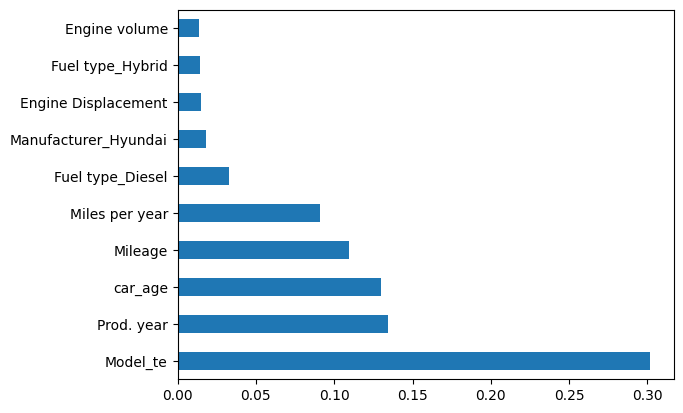

In [34]:
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [35]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 400, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

y_pred = search.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
-5008.982476251058
MAE: 4453.580692659814
R2: 0.7397922379266187


In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [1.0, 'sqrt', 0.5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

y_pred = search.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
-4883.100830764612
MAE: 4404.208629456571
R2: 0.7455679695895848


In [37]:
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)
y_pred = etr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4301.679965333648
R2: 0.7342240866143197


In [38]:
etr.feature_names_in_

array(['Prod. year', 'Engine volume', 'Mileage', 'Cylinders',
       'Gear box type', 'car_age', 'Engine Displacement',
       'Miles per year', 'Manufacturer_Audi', 'Manufacturer_BMW',
       'Manufacturer_Chevrolet', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Kia',
       'Manufacturer_Lexus', 'Manufacturer_Mazda',
       'Manufacturer_Mercedes-Benz', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen',
       'Manufacturer_other', 'Color_Beige', 'Color_Black', 'Color_Blue',
       'Color_Brown', 'Color_Gold', 'Color_Gray', 'Color_Green',
       'Color_Orange', 'Color_Purple', 'Color_Red', 'Color_Silver',
       'Color_White', 'Category_Coupe', 'Category_Hatchback',
       'Category_Pickup', 'Category_SUV', 'Category_Sedan',
       'Category_Van', 'Category_Wagon', 'Fuel type_Diesel',
       'Fuel type_Hybrid', 'Fuel type_Petrol', 'Drive wheels_AWD',
      